In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

import warnings
warnings.filterwarnings("ignore")

In [ ]:
nav = pd.read_csv("data/raw/nav_history.csv")

axis = pd.read_csv("data/raw/Axis_Bluechip.csv")

icici = pd.read_csv("data/raw/ICICI_Bluechip.csv")

kotak = pd.read_csv("data/raw/Kotak_Bluechip.csv")

nippon = pd.read_csv("data/raw/Nippon_Large_Cap.csv")

sbi = pd.read_csv("data/raw/SBI_Bluechip.csv")

fund = pd.read_csv("data/raw/fund_master.csv")

transactions = pd.read_csv("data/raw/investor_transactions.csv")

performance = pd.read_csv("data/raw/scheme_performance.csv")

aum = pd.read_csv("data/raw/aum_history.csv")

sip = pd.read_csv("data/raw/sip_inflows.csv")

category = pd.read_csv("data/raw/category_inflows.csv")

demographics = pd.read_csv("data/raw/investor_demographics.csv")

folio = pd.read_csv("data/raw/folio_counts.csv")

portfolio = pd.read_csv("data/raw/portfolio_holdings.csv")

In [ ]:
datasets = {
    "NAV": nav,
    "Axis": axis,
    "ICICI": icici,
    "Kotak": kotak,
    "Nippon": nippon,
    "SBI": sbi,
    "Transactions": transactions,
    "Performance": performance,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Demographics": demographics,
    "Folio": folio,
    "Portfolio": portfolio
}

for name, df in datasets.items():
    print("="*50)
    print(name)
    print(df.head())
    print(df.shape)
    

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
nav = pd.read_csv("data/raw/nav_history.csv")

axis = pd.read_csv("data/raw/Axis_Bluechip.csv")

icici = pd.read_csv("data/raw/ICICI_Bluechip.csv")

kotak = pd.read_csv("data/raw/Kotak_Bluechip.csv")

nippon = pd.read_csv("data/raw/Nippon_Large_Cap.csv")

sbi = pd.read_csv("data/raw/SBI_Bluechip.csv")

fund = pd.read_csv("data/raw/fund_master.csv")

transactions = pd.read_csv("data/raw/investor_transactions.csv")

performance = pd.read_csv("data/raw/scheme_performance.csv")

aum = pd.read_csv("data/raw/aum_history.csv")

sip = pd.read_csv("data/raw/sip_inflows.csv")

category = pd.read_csv("data/raw/category_inflows.csv")

demographics = pd.read_csv("data/raw/investor_demographics.csv")

folio = pd.read_csv("data/raw/folio_counts.csv")

portfolio = pd.read_csv("data/raw/portfolio_holdings.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


In [11]:
nav["date"] = pd.to_datetime(nav["date"], format="%d-%m-%Y")

nav = nav.sort_values("date")

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=nav["date"],
        y=nav["nav"],
        mode="lines",
        name="NAV"
    )
)

fig.update_layout(
    title="Daily NAV Trend",
    xaxis_title="Date",
    yaxis_title="NAV"
)

# Save chart as PNG
fig.write_image("reports/charts/nav_trend.png")

# Display chart
fig.show()

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


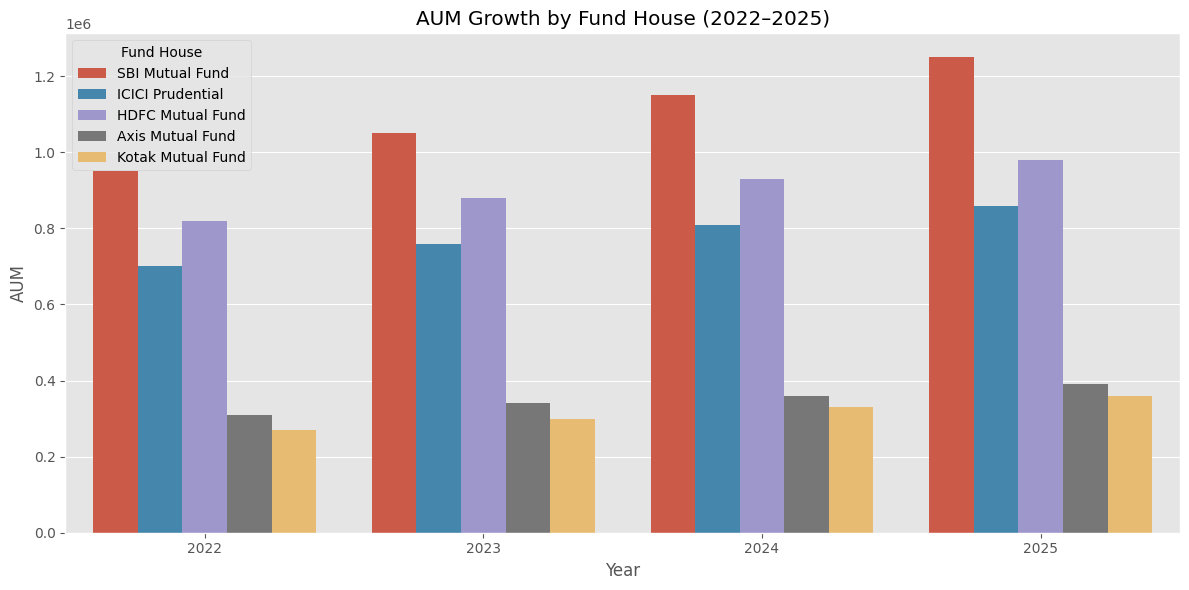

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM")

plt.legend(title="Fund House")

plt.tight_layout()

plt.savefig("reports/aum_growth.png")

plt.show()

In [6]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_amount",
    markers=True,
    title="Monthly SIP Inflow (2022–2025)"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr (Highest)",
    showarrow=True,
    arrowhead=2
)

fig.show()

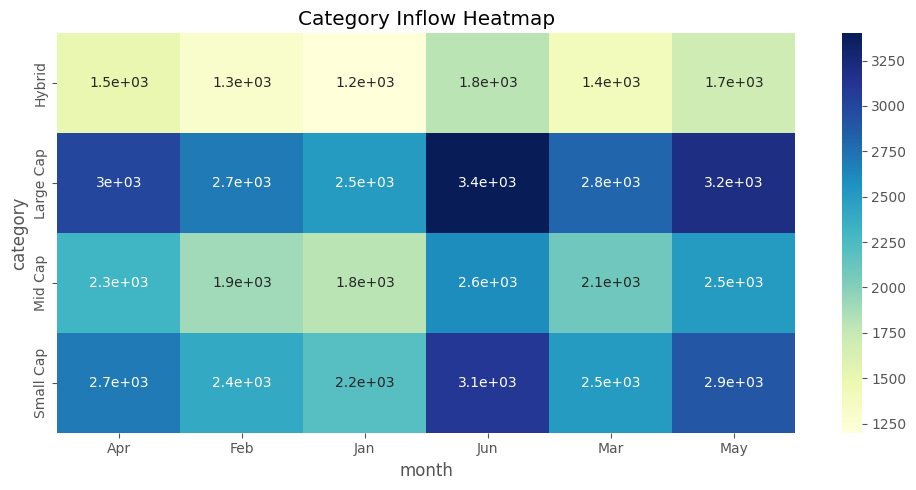

In [7]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="inflow"
)

plt.figure(figsize=(10,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.tight_layout()

plt.savefig("reports/category_heatmap.png")

plt.show()

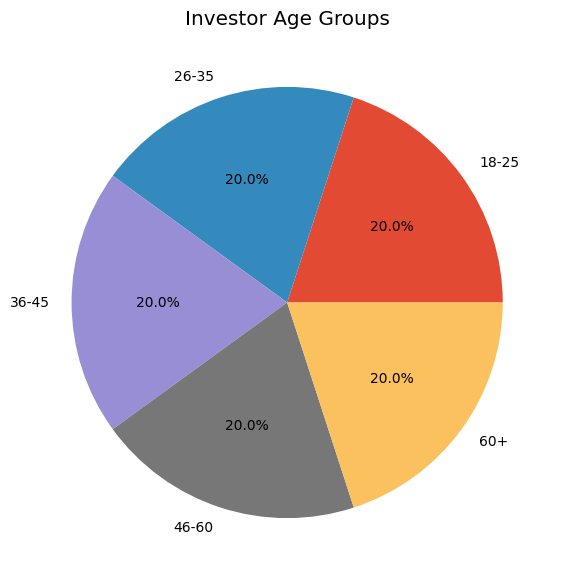

In [8]:
age = demographics["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age,
    labels=age.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Groups")

plt.savefig("reports/age_group.png")

plt.show()

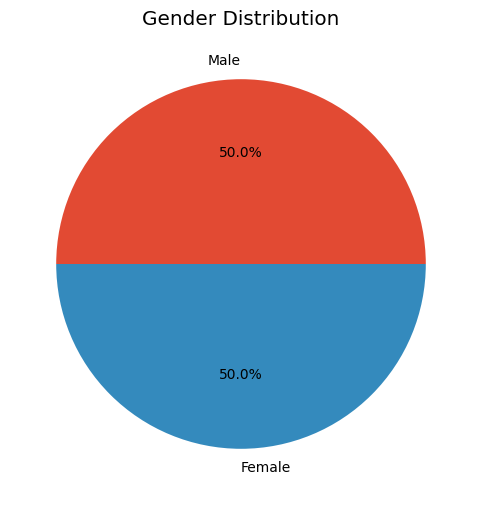

In [9]:
gender = demographics["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.savefig("reports/gender.png")

plt.show()

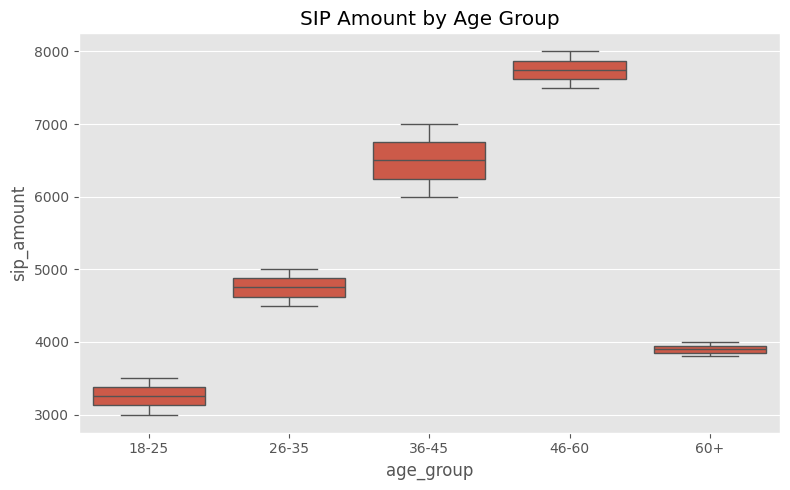

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=demographics,
    x="age_group",
    y="sip_amount"
)

plt.title("SIP Amount by Age Group")

plt.tight_layout()

plt.savefig("reports/sip_boxplot.png")

plt.show()

In [15]:
plt.tight_layout()

plt.savefig("reports/charts/aum_growth.png")

plt.show()

<Figure size 640x480 with 0 Axes>

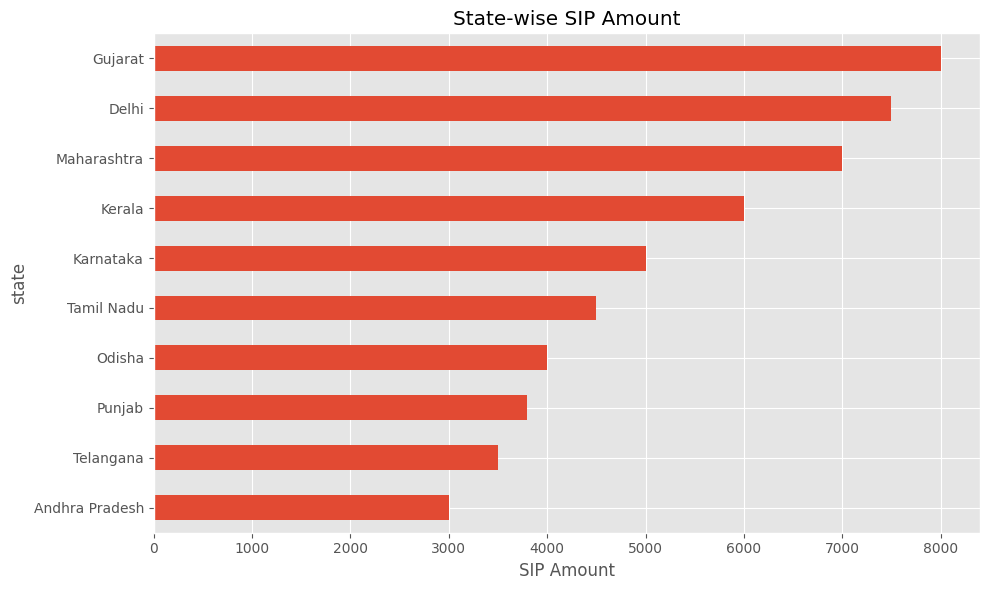

In [16]:
plt.figure(figsize=(10,6))

state_sip = demographics.groupby("state")["sip_amount"].sum()

state_sip = state_sip.sort_values()

state_sip.plot(kind="barh")

plt.title("State-wise SIP Amount")

plt.xlabel("SIP Amount")

plt.tight_layout()

plt.savefig("reports/charts/state_wise_sip.png")

plt.show()

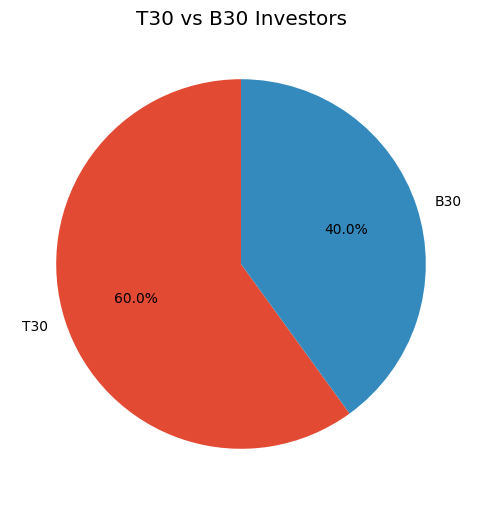

In [17]:
tier = demographics["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investors")

plt.savefig("reports/charts/t30_b30.png")

plt.show()

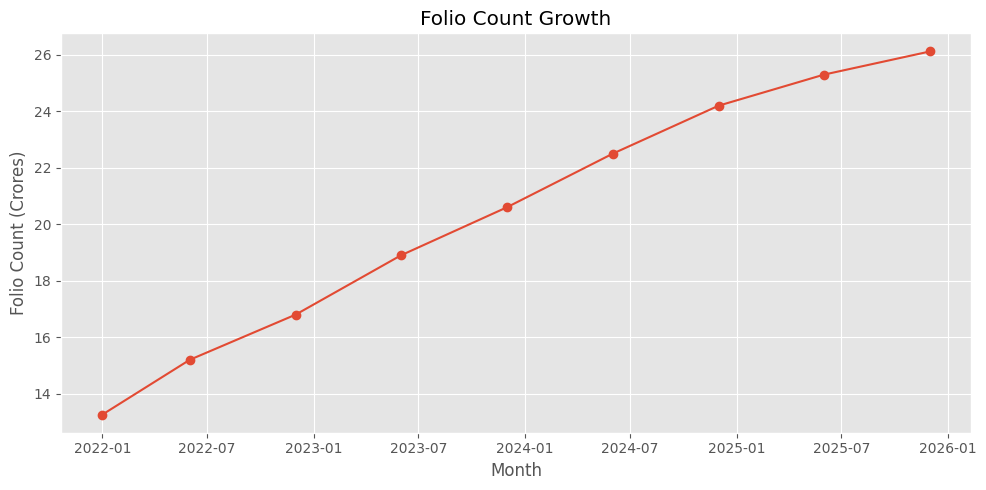

In [18]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(10,5))

plt.plot(
    folio["month"],
    folio["folio_count"],
    marker="o"
)

plt.title("Folio Count Growth")

plt.xlabel("Month")

plt.ylabel("Folio Count (Crores)")

plt.grid(True)

plt.tight_layout()

plt.savefig("reports/charts/folio_growth.png")

plt.show()

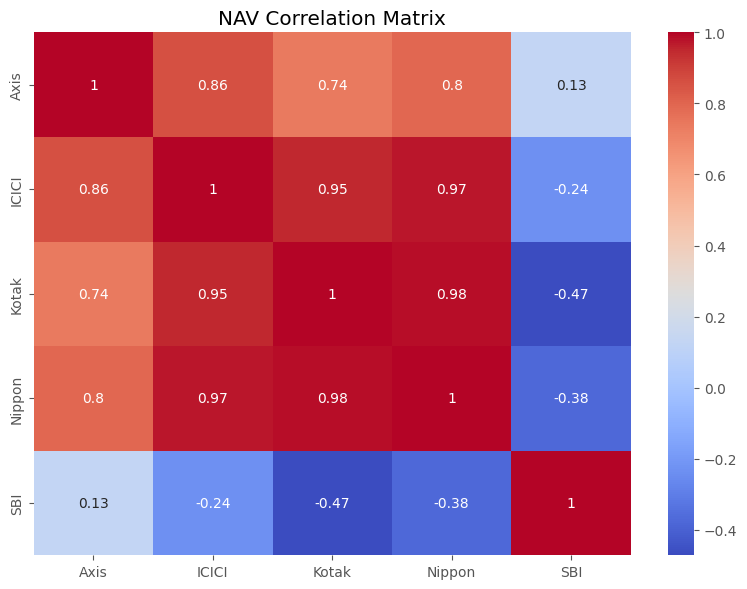

In [19]:
returns = pd.DataFrame({
    "Axis": axis["nav"],
    "ICICI": icici["nav"],
    "Kotak": kotak["nav"],
    "Nippon": nippon["nav"],
    "SBI": sbi["nav"]
})

corr = returns.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Correlation Matrix")

plt.tight_layout()

plt.savefig("reports/charts/correlation_matrix.png")

plt.show()

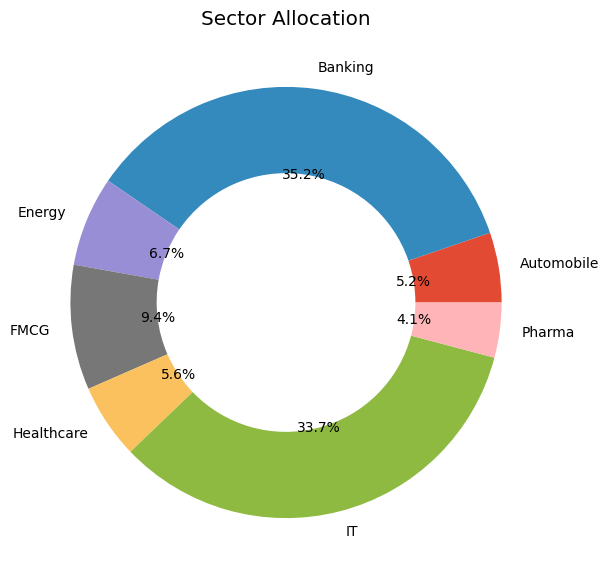

In [20]:
sector = portfolio.groupby("sector")["weight"].sum()

plt.figure(figsize=(7,7))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation")

plt.savefig("reports/charts/sector_donut.png")

plt.show()

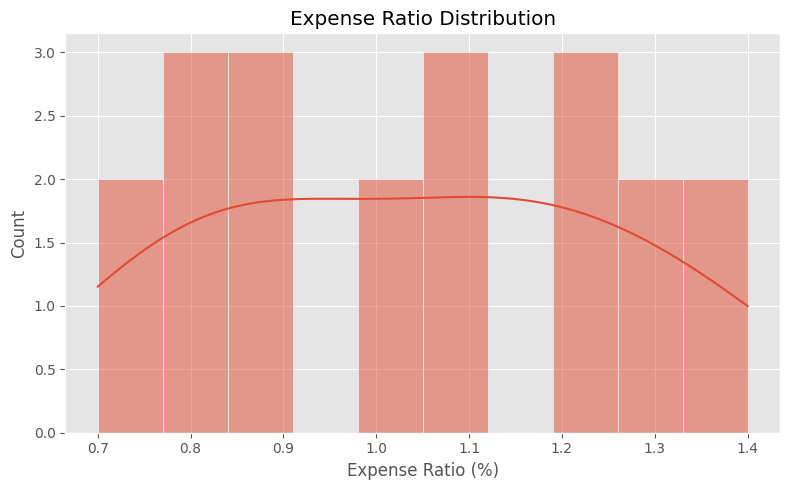

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    performance["expense_ratio"],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("reports/charts/expense_ratio_distribution.png")

plt.show()

In [23]:
print(performance.columns)

Index(['scheme_code', 'return_1y', 'return_3y', 'return_5y', 'expense_ratio'], dtype='str')


<Figure size 1000x600 with 0 Axes>

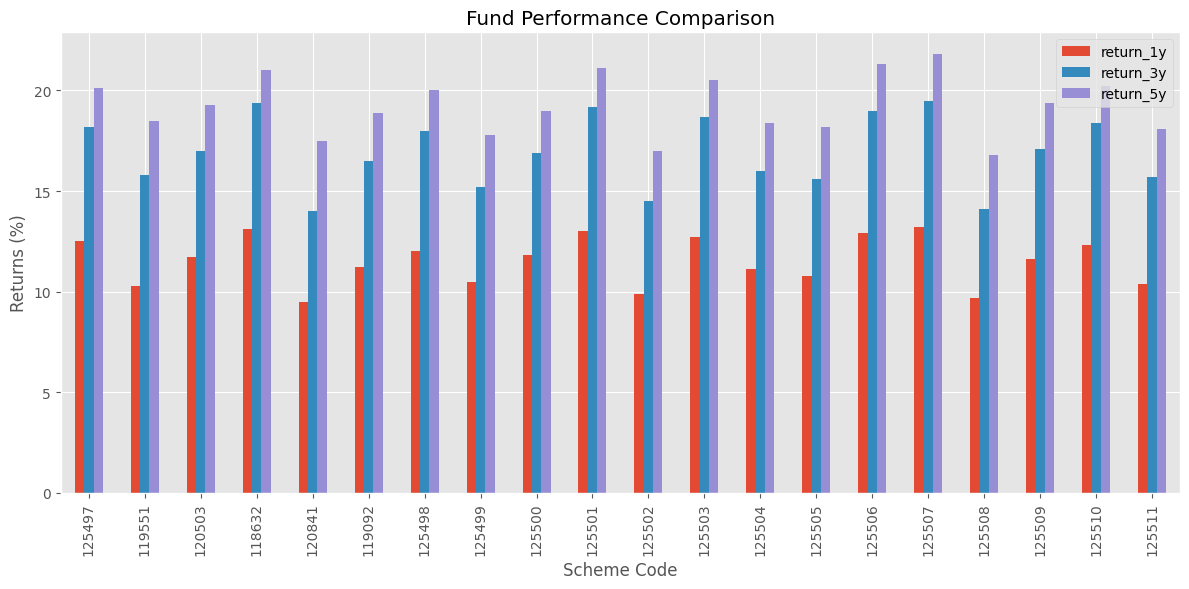

In [24]:
plt.figure(figsize=(10,6))

performance.plot(
    x="scheme_code",
    y=["return_1y", "return_3y", "return_5y"],
    kind="bar",
    figsize=(12,6)
)

plt.title("Fund Performance Comparison")
plt.xlabel("Scheme Code")
plt.ylabel("Returns (%)")

plt.tight_layout()

plt.savefig("reports/charts/fund_returns.png")

plt.show()

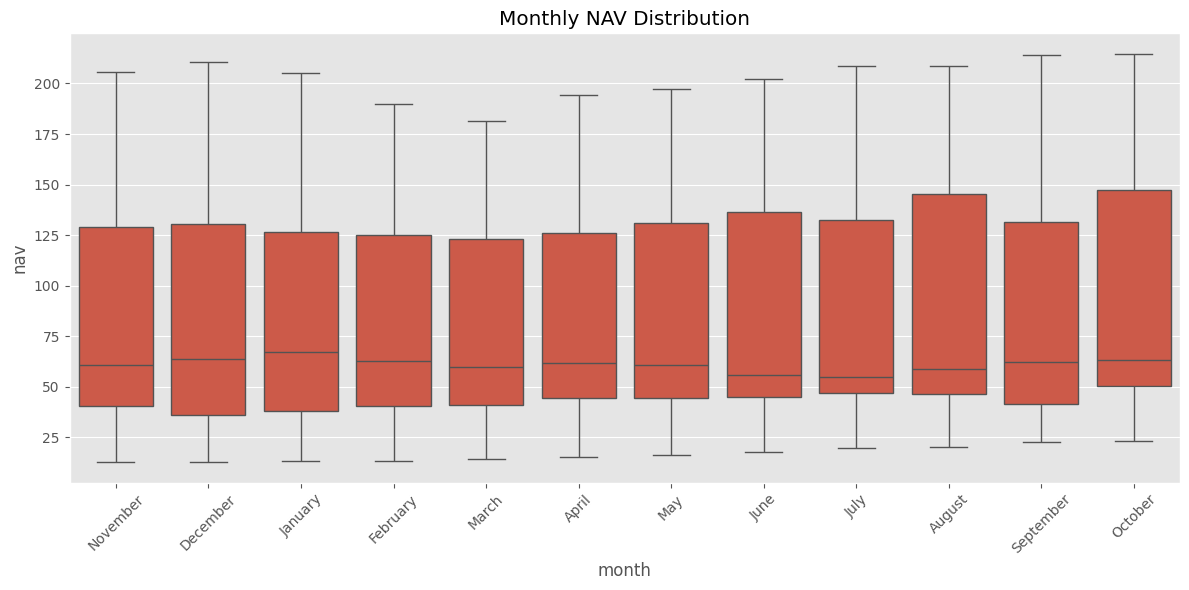

In [25]:
nav["month"] = pd.to_datetime(nav["date"]).dt.month_name()

plt.figure(figsize=(12,6))

sns.boxplot(
    data=nav,
    x="month",
    y="nav"
)

plt.xticks(rotation=45)

plt.title("Monthly NAV Distribution")

plt.tight_layout()

plt.savefig("reports/charts/monthly_nav_distribution.png")

plt.show()

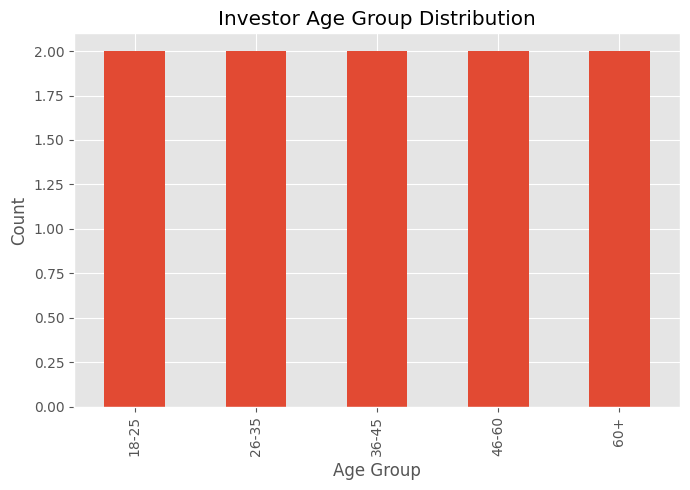

In [26]:
plt.figure(figsize=(7,5))

demographics["age_group"].value_counts().plot(kind="bar")

plt.title("Investor Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("reports/charts/age_group_distribution.png")

plt.show()

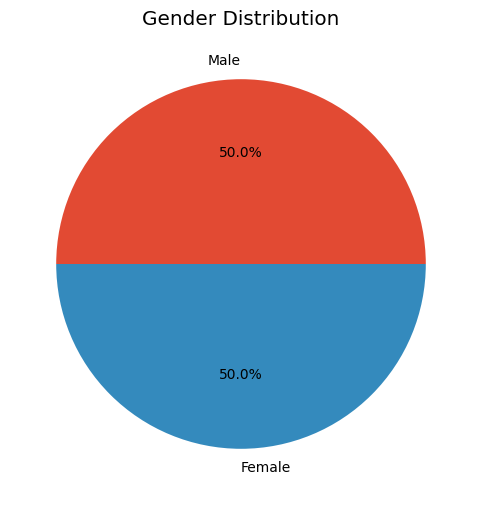

In [27]:
plt.figure(figsize=(6,6))

demographics["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Gender Distribution")

plt.savefig("reports/charts/gender_distribution.png")

plt.show()

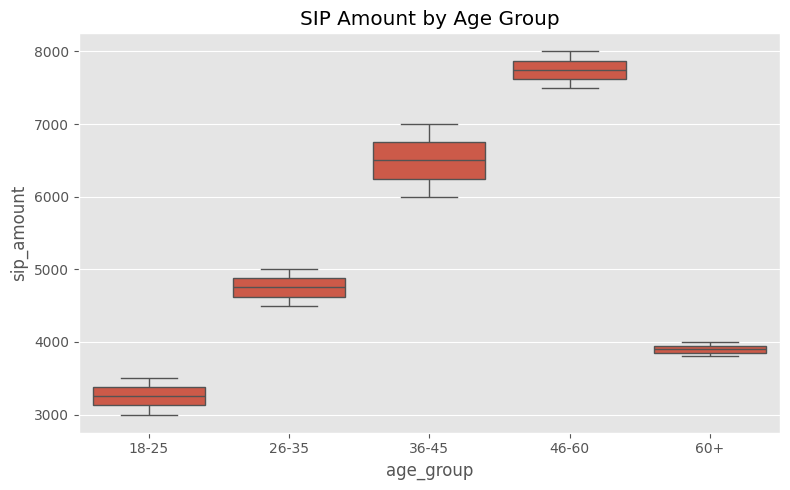

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=demographics,
    x="age_group",
    y="sip_amount"
)

plt.title("SIP Amount by Age Group")

plt.tight_layout()

plt.savefig("reports/charts/sip_amount_age_group.png")

plt.show()

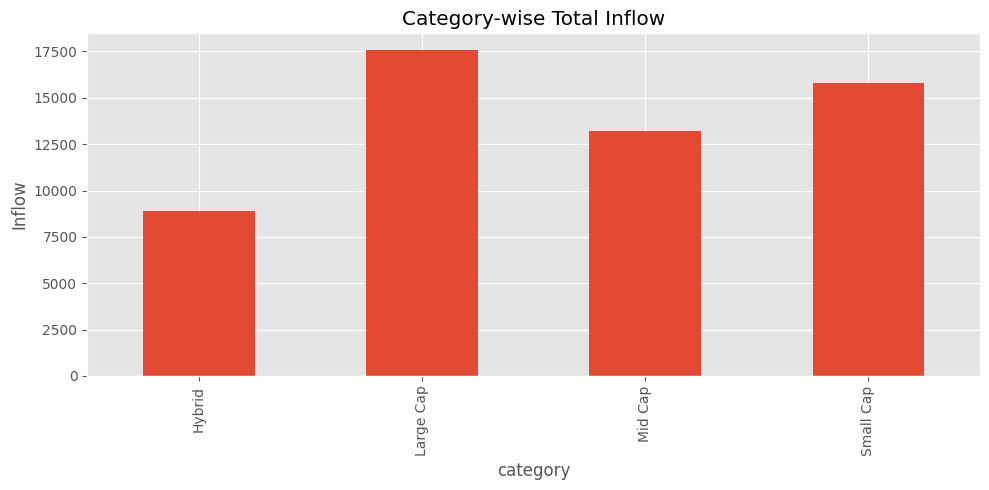

In [29]:
plt.figure(figsize=(10,5))

category.groupby("category")["inflow"].sum().plot(kind="bar")

plt.title("Category-wise Total Inflow")

plt.ylabel("Inflow")

plt.tight_layout()

plt.savefig("reports/charts/category_inflow_bar.png")

plt.show()

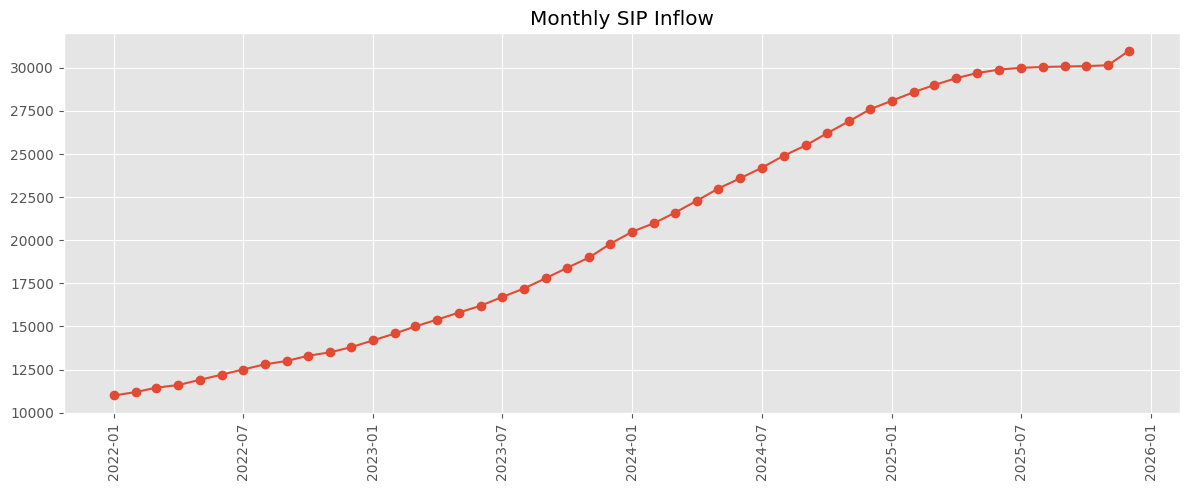

In [30]:
plt.figure(figsize=(12,5))

plt.plot(
    sip["month"],
    sip["sip_amount"],
    marker="o"
)

plt.xticks(rotation=90)

plt.title("Monthly SIP Inflow")

plt.tight_layout()

plt.savefig("reports/charts/sip_monthly_trend.png")

plt.show()

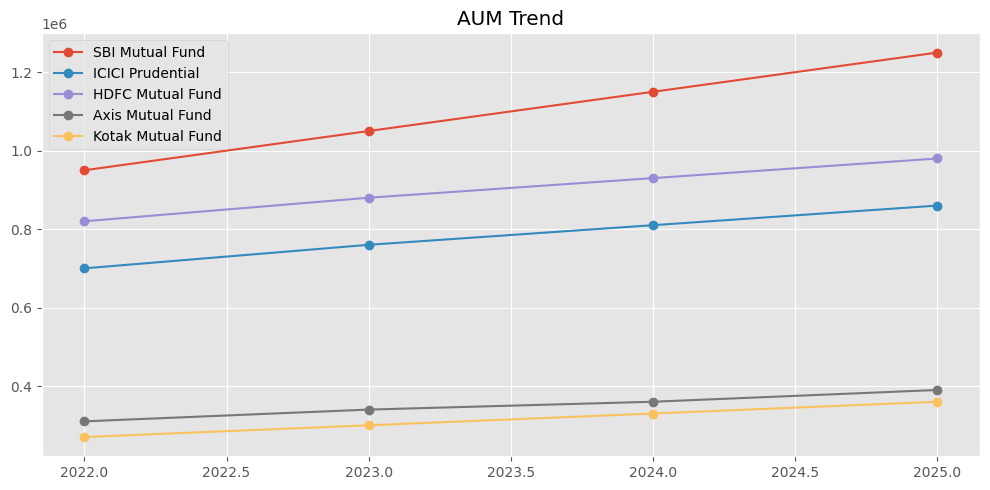

In [31]:
plt.figure(figsize=(10,5))

for fund in aum["fund_house"].unique():
    temp = aum[aum["fund_house"] == fund]
    plt.plot(temp["year"], temp["aum"], marker="o", label=fund)

plt.legend()

plt.title("AUM Trend")

plt.tight_layout()

plt.savefig("reports/charts/aum_trend.png")

plt.show()